# Classification of Breast Cancer with ResNet

Giorgia Cappellato 5410259

Andrea Frattesi 5411003


## Introduction

According to the World Health Organization (WHO), breast cancer is the most prevalent cancer among women worldwide, affecting populations in over 150 countries. Early detection plays a crucial role in improving survival rates and treatment outcomes, making the development of reliable and automated diagnostic tools a key research priority.

In this project, we explore the application of Deep Learning techniques to breast cancer analysis using medical imaging data. Specifically, we focus on two complementary tasks:

- Classification, to determine the presence and type of breast cancer (benign, malignant, or normal) from grayscale medical images using a Convolutional Neural Network (CNN) based on the ResNet architecture.
- Segmentation, to accurately identify and localize cancerous tissue regions within images using a U-Net architecture, leveraging pixel-level annotations.

## Dataset

The dataset used in this project was downloaded from Kaggle and contains 780 grayscale breast images, collected over approximately one year at Baheya Hospital.
Each image is associated with segmentation masks for benign and malignant cases.
The dataset is composed of the following classes:

- Benign: 487 images
- Malignant: 210 images
- Normal: 133 images

## Project Goals

The main objectives of this notebook are:
- To preprocess and analyze the dataset.
- To train and evaluate a CNN-based model for breast cancer classification.
- To train a U-Net model for medical image segmentation.
- To assess model performance using appropriate evaluation metrics and visual results.

This notebook documents the full experimental pipeline, from data loading and preprocessing to model training, evaluation, and result interpretation.

## Libraries

In [ ]:
import torch
import torchvision
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split,  Dataset
import torch.nn as nn

import numpy as np
import os
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, roc_curve, auc, confusion_matrix
from sklearn.preprocessing import label_binarize

import matplotlib.pyplot as plt
from itertools import cycle

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Checking which device we are using

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available() :
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f'Using: {device}')

Using: cuda


First of all we want to check the mode of both images and their masks, which also gives insight into the number of channels they carry.

In [ ]:
def check_image_mode(image_path):
    with Image.open(image_path) as img:
        mode = img.mode
        print(f'The mode of the image '{image_path}' is: {mode}')
        if mode == 'L':
            print(f'The image at {image_path} is grayscale.')
        elif mode == 'RGB':
            print(f'The image at {image_path} is colorful (RGB).')
        else:
            print(f'The image at {image_path} is in {mode} mode, which is not standard for grayscale or RGB.')

image_path = '/content/drive/MyDrive/Breast Cancer Detection/dataset/benign/benign (434).png'
check_image_mode(image_path)

mask_path = '/content/drive/MyDrive/Breast Cancer Detection/dataset/benign/benign (434)_mask.png'
check_image_mode(mask_path)

The mode of the image '/content/drive/MyDrive/Breast Cancer Detection/dataset/benign/benign (434).png' is: RGB
The image at /content/drive/MyDrive/Breast Cancer Detection/dataset/benign/benign (434).png is colorful (RGB).
The mode of the image '/content/drive/MyDrive/Breast Cancer Detection/dataset/benign/benign (434)_mask.png' is: 1
The image at /content/drive/MyDrive/Breast Cancer Detection/dataset/benign/benign (434)_mask.png is in 1 mode, which is not standard for grayscale or RGB.


Let us define a class which we will use to load our data.

The class `ScanWithMaskDataset` handles the data where an image has one or more masks.

First of all, it assumes that `root_dir` contains subdirectories for each class (benign, malignant, normal), with images and their masks stored together. Furthermore, the transform parameter supports image preprocessing.

It works by loading and pairing images with their masks, stacking them as additional channels.

In [ ]:
class ScanWithMaskDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.dataset = datasets.ImageFolder(root=root_dir)
        self.classes = self.dataset.classes
        self.class_to_idx = self.dataset.class_to_idx
        self.samples = self._load_samples()

    def _load_samples(self):
        samples = []
        for class_name in self.classes:
            class_path = os.path.join(self.root_dir, class_name)
            files = [f for f in os.listdir(class_path) if f.endswith('.png') and not '_mask' in f]
            for file in files:
                image_path = os.path.join(class_path, file)
                base_filename = os.path.splitext(file)[0]
                mask_files = [mf for mf in os.listdir(class_path) if mf.startswith(base_filename) and '_mask' in mf]
                mask_paths = [os.path.join(class_path, mf) for mf in mask_files]
                for mask_path in mask_paths:
                    samples.append((image_path, mask_path, self.class_to_idx[class_name]))
        return samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        image_path, mask_path, class_idx = self.samples[idx]

        image = Image.open(image_path)
        mask = Image.open(mask_path).convert('L')

        if self.transform:
            image = self.transform(image)
            mask = self.transform(mask)

        # Stack the image and mask as separate channels
        combined = torch.cat((image, mask), dim=0)

        return combined, class_idx

dataset = ScanWithMaskDataset(root_dir='/content/drive/MyDrive/Breast Cancer Detection/dataset')

In [ ]:
dataset.samples[:5]

[('/content/drive/MyDrive/Breast Cancer Detection/dataset/benign/benign (106).png',
  '/content/drive/MyDrive/Breast Cancer Detection/dataset/benign/benign (106)_mask.png',
  0),
 ('/content/drive/MyDrive/Breast Cancer Detection/dataset/benign/benign (10).png',
  '/content/drive/MyDrive/Breast Cancer Detection/dataset/benign/benign (10)_mask.png',
  0),
 ('/content/drive/MyDrive/Breast Cancer Detection/dataset/benign/benign (100).png',
  '/content/drive/MyDrive/Breast Cancer Detection/dataset/benign/benign (100)_mask.png',
  0),
 ('/content/drive/MyDrive/Breast Cancer Detection/dataset/benign/benign (100).png',
  '/content/drive/MyDrive/Breast Cancer Detection/dataset/benign/benign (100)_mask_1.png',
  0),
 ('/content/drive/MyDrive/Breast Cancer Detection/dataset/benign/benign (1).png',
  '/content/drive/MyDrive/Breast Cancer Detection/dataset/benign/benign (1)_mask.png',
  0)]

## Data Transformation

### Training Data Transformations
The training data undergoes a series of transformations to enhance the model's ability to generalize from the training dataset to unseen data. This is achieved through:
- *Resizing and cropping* to maintain consistency in image dimensions across all inputs, which is crucial for the neural network to process them effectively.
- *Data augmentation techniques* like random flips and rotations introduce variability into the dataset, simulating different viewing conditions. This helps prevent the model from overfitting and improves its robustness and performance on new, unseen images.

### Testing Data Transformations
For the testing data, transformations are kept minimal to evaluate the model's performance under consistent and controlled conditions:
- *Resizing and center cropping* are applied to match the input size used during training, ensuring that each image is evaluated in a uniform manner.
- *No random augmentations* are used in testing to ensure the data reflects real-world scenarios without artificial modifications.

These transformations are essential for preparing the images in a format suitable for the neural network and facilitate both effective training and accurate evaluation.

In [ ]:
train_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.RandomHorizontalFlip(), # Data augmentation
    transforms.RandomVerticalFlip(), # Data augmentation
    transforms.RandomRotation(10) # Data augmentation
])

test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
])

In [ ]:
# Splitting the dataset into train and test sets
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# Applying different transforms to the test dataset
train_dataset.dataset.transform = train_transforms
test_dataset.dataset.transform = test_transforms

# DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
# Extract class labels
class_labels = dataset.classes
print(f'Class labels: {class_labels}')

Class labels: ['benign', 'malignant', 'normal']


## Residual Networks

Next step is to load a pretrained ResNet model and apply some modifications to it to have the mask of the image as an additional input channel.

**ResNet (Residual Neural Network)** introduces residual connections (also known as skip connections)  which allow the network to learn residual mappings instead of directly learning the desired underlying function.
This design helps mitigate the vanishing gradient problem, a common issue in deep neural networks where gradients become too small during backpropagation, slowing down or preventing effective learning. By providing a direct path for gradient flow across layers, residual connections enable deeper networks to converge more efficiently and achieve better performance.
Specifically, in ResNet architectures, shortcut connections are added between pairs of convolutional layers, allowing the network to bypass one or more layers when beneficial.

In [ ]:
# Load a pretrained ResNet model
model = models.resnet18(pretrained=True)

# Modify the first convolutional layer to have 4 instead of 3 channels
model.conv1 = nn.Conv2d(4, 64, kernel_size=7, stride=2, padding=3, bias=False)

for param in model.parameters():
    param.requires_grad = False

# Modify the final fully connected layer to match the number of classes
num_features = model.fc.in_features  # Get the number of input features of the last layer
model.fc = nn.Linear(num_features, 3)  # 3 classes: no cancer, benign, malignant

model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:00<00:00, 168MB/s]


In [ ]:
model

ResNet(
  (conv1): Conv2d(4, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## Model Training Components

### Loss Function
**CrossEntropyLoss**: Used as the loss function, it is particularly suited for classification tasks with multiple classes. This function calculates the difference between the predicted probabilities and the true distribution (the actual labels), effectively measuring the performance of the model during training. The goal is to minimize this loss, which indicates better model predictions.

### Optimizer
**Stochastic Gradient Descent (SGD)**: The optimizer chosen to update the model's weights based on the gradients of the loss function. Specific parameters include:
  - **Learning Rate (0.001)**: Determines how much to change the model in response to the estimated error each time the model weights are updated.
  - **Momentum (0.9)**: Helps to accelerate gradients vectors in the right directions, thus leading to faster converging. It incorporates the 'velocity' of the gradients to smooth out the updates.
  - **Nesterov Accelerated Gradient (Nesterov=True)**: An improvement on traditional momentum, it looks ahead by calculating gradient not at the current parameters but at the lookahead parameters.
  - **Weight Decay (0.00001)**: Adds a regularization term to the loss to prevent the weights from growing too large; only weights need to be regularized.

### Learning Rate Scheduler
**StepLR**: Adjusts the learning rate according to a step policy, useful for controlling and adjusting the learning rate during training:
  - **Step Size (10)**: The learning rate is decayed every 10 epochs.
  - **Gamma (0.1)**: Determines the factor by which the learning rate will be reduced. Every 10 epochs, the learning rate is multiplied by 0.1, effectively dropping the learning rate to prevent overshooting the minimum of the loss landscape as the training progresses.

Note that the specific hyperparameters were chosen based on their performance.


In [ ]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9, nesterov=True, weight_decay=0.00001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

## Training and Testing

In [ ]:
for epoch in range(30):

    # Setting the model to training mode
    model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass: Compute predicted label by passing the image to the model
        output = model(images)

        # Compute loss
        loss = criterion(output, labels)

        # Backpropagation steps
        optimizer.zero_grad() # Clear gradients before calculating them
        loss.backward() # Calculate gradients
        optimizer.step() # Update model parameters

    # Validation every 5 epochs
    if epoch % 5 != 0:
        continue

    print(f'Epoch {epoch}/30')
    print('-' * 10)
    print(f'Epoch {epoch} loss: {loss.item()}')

    scheduler.step()

    # Setting the model to evaluation mode
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            output = model(images)
            _, predicted = torch.max(output, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f'Epoch {epoch} accuracy: {correct / total}')
    print()

Epoch 0/30
----------
Epoch 0 loss: 0.6532220244407654
Epoch 0 accuracy: 0.6

Epoch 5/30
----------
Epoch 5 loss: 0.3951702117919922
Epoch 5 accuracy: 0.9

Epoch 10/30
----------
Epoch 10 loss: 0.2247636318206787
Epoch 10 accuracy: 0.90625

Epoch 15/30
----------
Epoch 15 loss: 0.3101772367954254
Epoch 15 accuracy: 0.9125

Epoch 20/30
----------
Epoch 20 loss: 0.1316937804222107
Epoch 20 accuracy: 0.91875

Epoch 25/30
----------
Epoch 25 loss: 0.1977883279323578
Epoch 25 accuracy: 0.90625



## Model Evaluation

During the evaluation phase, the model is set to `model.eval()` mode to deactivate dropout and normalize with batch statistics, ensuring consistent behavior. Using `torch.no_grad()`, the model predicts over the test set, computing loss and key metrics like accuracy, precision, recall, and F1 score. This step is crucial for assessing the model's performance on unseen data, highlighting its effectiveness and areas for potential improvement.

In [ ]:
model.eval()

with torch.no_grad():
    all_preds = []
    all_labels = []
    test_loss = 0.0

    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)
        test_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    test_loss = test_loss / len(test_loader.dataset)

    accuracy = accuracy_score(all_labels, all_preds)

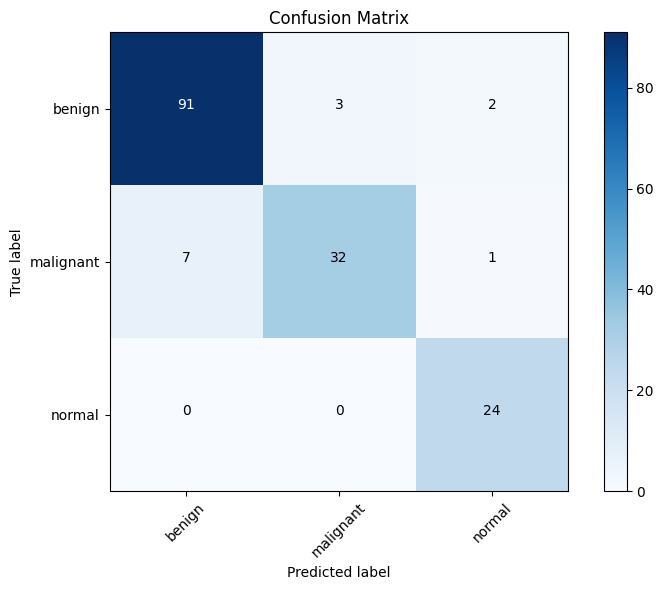

In [ ]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(dataset.classes))
plt.xticks(tick_marks, dataset.classes, rotation=45)
plt.yticks(tick_marks, dataset.classes)

thresh = cm.max() / 2.
for i, j in np.ndindex(cm.shape):
    plt.text(j, i, f'{cm[i, j]}',
             horizontalalignment='center',
             color='white' if cm[i, j] > thresh else 'black')

plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

The confusion matrix shows the classification performance for the three categories.

The model is highly effective at identifying normal cases with high accuracy. Results for cancerous scans are impressive. However, some confusion between classes suggests the need for improved feature distinction or model tuning to better differentiate these conditions.

## ROC Curve
A Receiver Operating Characteristic (ROC) curve is a graphical plot used to show the diagnostic ability of a binary classifier system as its discrimination threshold is varied. It plots two parameters:
- **True Positive Rate (TPR)**: Also known as sensitivity, it measures the proportion of actual positives correctly identified by the model.
- **False Positive Rate (FPR)**: Measures the proportion of actual negatives that are incorrectly classified as positives.

They provide an overview of the trade-off between sensitivity (TPR) and specificity (1 - FPR) across different thresholds. The area under the ROC curve (AUC) gives a single scalar value to rate performance. A higher AUC value indicates a better performing model, with 1.0 representing perfect prediction and 0.5 denoting a result no better than random chance.

This tool is crucial in evaluating and comparing the performance of different classification models, especially in fields like medicine where the costs of false negatives and false positives are significantly different.

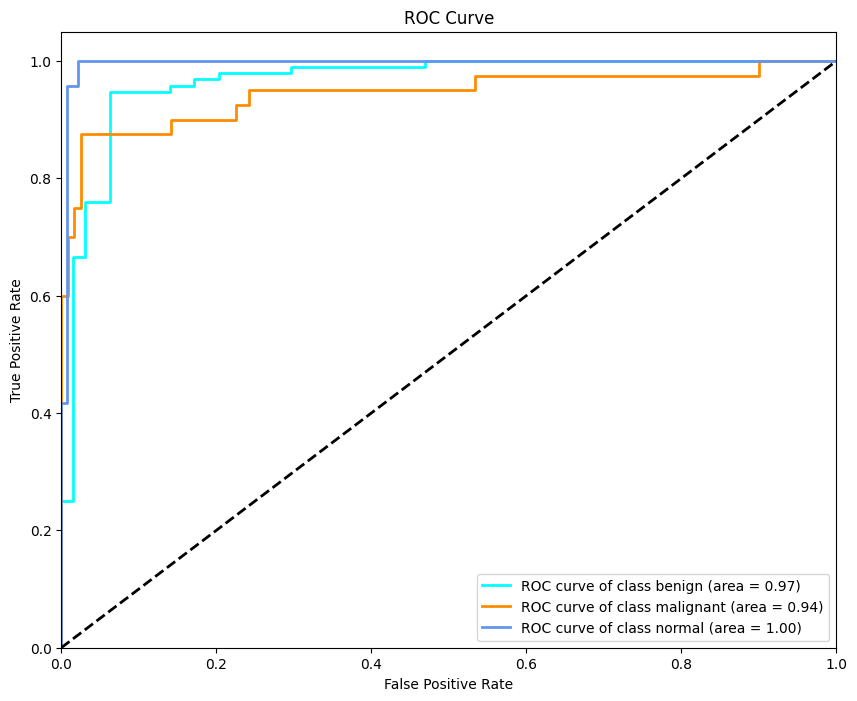

In [ ]:
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = torch.nn.functional.softmax(outputs, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# Convert to numpy arrays
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# Binarize the labels
n_classes = len(dataset.classes)
all_labels_binarized = label_binarize(all_labels, classes=range(n_classes))

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(all_labels_binarized[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 8))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'red', 'green'])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of class {dataset.classes[i]} (area = {roc_auc[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

As the plot shows, the model performs very well.

The area under the curve (AUC) for no cancer class is equal to 1, which suggests that our predictions are almost entirely correct. For benign and malignant classes, the AUC is equal to, respectively, 0.97 and 0.94.

In [ ]:
# Save the model

from datetime import datetime

save_dir = '/content/drive/MyDrive/Breast Cancer Detection/models_mask'
os.makedirs(save_dir, exist_ok=True)

filename = datetime.now().strftime('%Y-%m-%d_%H-%M-%S') + '_model.pth'
model_pth_name = os.path.join(save_dir, filename)

torch.save(model, model_pth_name)

## References

https://www.kaggle.com/datasets/aryashah2k/breast-ultrasound-images-dataset

https://www.sciencedirect.com/science/article/pii/S2352340919312181?via%3Dihub#tbl1